# Palm Tree Classification Pipeline using ConvNeXt Small

## Introduction
This notebook implements a complete deep learning pipeline to classify palm tree images using transfer learning with the ConvNeXt Small architecture.

## Key techniques used in this pipeline
- **K-Fold Cross Validation**: Split the data into multiple folds (default 5) and train separate models to obtain robust, reliable results.
- **MixUp Augmentation**: Blend images and labels during training to reduce overfitting and improve generalization.
- **Differential Learning Rates**: Apply different learning rates to different parts of the model (slow for early layers, faster for the classifier head).
- **Test Time Augmentation (TTA)**: During inference, evaluate the image and its horizontal flip, then average predictions to improve accuracy.


# 1. Imports and Configuration

Here we import the necessary libraries (PyTorch, Pandas, Scikit-Learn) and set up our hardware configuration. We also define our hyperparameters here so they are easy to change in one place.

**Batch Size:** 64 (Optimized for ConvNeXt Small)  
**Epochs:** 100 (Long training run for maximum convergence)  
**MixUp:** Enabled with Alpha 0.4


In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

import os
# Allow duplication for some libraries to prevent conflicts
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import copy
from PIL import Image
from tqdm import tqdm
import multiprocessing

# --- CONFIGURATION ---
# Use CUDA (Nvidia GPU) if available, otherwise CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device set to: {DEVICE}")

# Dataset Path
DATASET_BASE_PATH = r"/mnt/c/Users/klood/Desktop/Grad project/cnn_classfication/final_models/farm_test/train_new_final"

# --- HYPERPARAMETERS ---
SELECTED_MODEL_NAME = "convnext_small"
IMG_SIZE = 224
NUM_EPOCHS = 100
BATCH_SIZE = 64
EARLY_STOP_PATIENCE = 10

# Regularization settings
DEFAULT_DROPOUT_RATE = 0.6 
DEFAULT_WEIGHT_DECAY = 0.02 

# Data Augmentation Strength
DEFAULT_P_FLIP = 0.5        
DEFAULT_P_AFFINE = 0.4      

# MixUp Settings
USE_MIXUP = True   
MIXUP_ALPHA = 0.4  
NUM_WORKERS = multiprocessing.cpu_count()

def format_time(minutes):
    """Converts minutes to a more readable format."""
    if minutes < 1:
        return f"{minutes*60:.0f} seconds"
    elif minutes >= 60:
        hours = int(minutes / 60)
        mins = int(minutes % 60)
        return f"{hours}h {mins}m"
    else:
        return f"{minutes:.2f} minutes"
    
class EarlyStopping:
    """
    Stops training if validation loss doesn't improve after a given patience.
    """
    def __init__(self, patience=10, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

Device set to: cuda


## 2. Exploratory Data Analysis (EDA)

Before training, we must inspect our data. This block checks:

- **Class Imbalance:** Are there enough images for every class? If one class has very few images, the model might ignore it.
- **Image Integrity:** We try to open a few images to ensure the paths are correct and the files are not corrupted.

--- Starting Exploratory Data Analysis (EDA) ---
Detected Classes: ['KHALAS', 'RAZEEZ', 'SHISHI']
Class Distribution: {'KHALAS': 2004, 'RAZEEZ': 2747, 'SHISHI': 1859}
Total Images: 6610


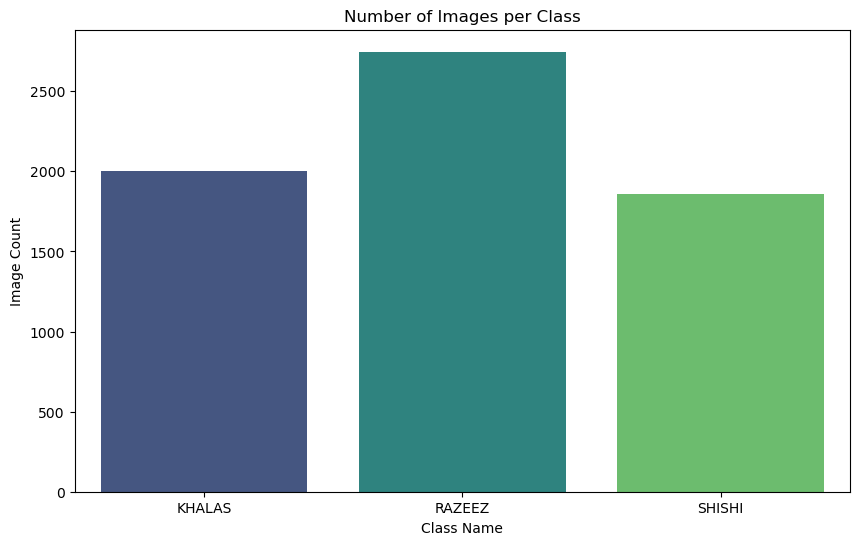

Displaying sample images...


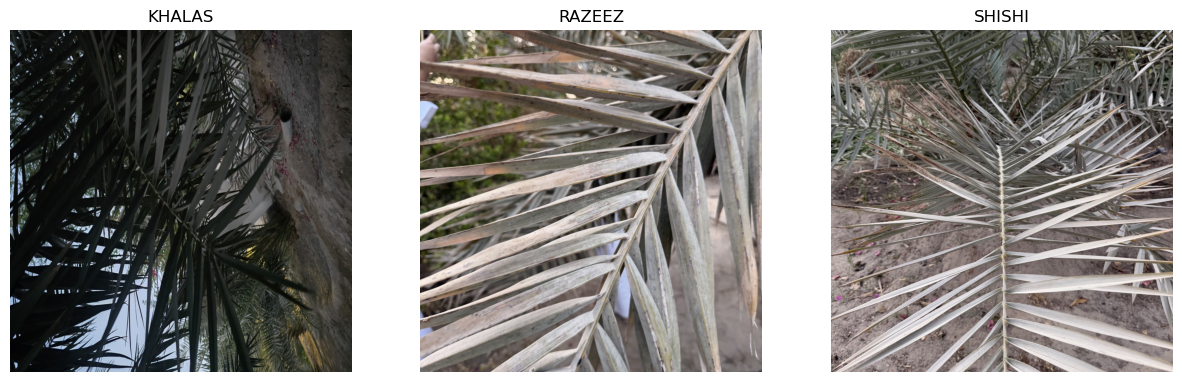

--- EDA Complete ---


In [2]:
def run_eda(dataset_path):
    print("--- Starting Exploratory Data Analysis (EDA) ---")
    
    if not os.path.exists(dataset_path):
        print(f"Error: Dataset path not found at {dataset_path}")
        return

    # 1. Load basic dataset info
    temp_dataset = datasets.ImageFolder(root=dataset_path)
    classes = temp_dataset.classes
    class_counts = {c: 0 for c in classes}
    
    for _, label_idx in temp_dataset.samples:
        class_counts[classes[label_idx]] += 1
        
    print(f"Detected Classes: {classes}")
    print(f"Class Distribution: {class_counts}")
    print(f"Total Images: {len(temp_dataset)}")
    
    # 2. Plot Class Distribution
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette="viridis")
    plt.title("Number of Images per Class")
    plt.xlabel("Class Name")
    plt.ylabel("Image Count")
    plt.show()
    
    # 3. Show Sample Images
    print("Displaying sample images...")
    fig, axes = plt.subplots(1, len(classes), figsize=(15, 5))
    
    for i, class_name in enumerate(classes):
        class_path = os.path.join(dataset_path, class_name)
        if os.path.exists(class_path) and len(os.listdir(class_path)) > 0:
            img_name = os.listdir(class_path)[0]
            img_path = os.path.join(class_path, img_name)
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(class_name)
            axes[i].axis('off')
        
    plt.show()
    print("--- EDA Complete ---")

# Run the EDA function
run_eda(DATASET_BASE_PATH)

## 3. Data Transformations & MixUp Logic

This section defines how we modify images before the AI sees them.

**What is MixUp?**  
Instead of showing the AI a picture of just a "Tree" or just a "Background", we mathematically blend them (e.g., 60% Tree + 40% Background). The AI must then predict "60% Tree, 40% Background". This prevents the AI from being overconfident and helps it generalize better.

**Augmentations Used:**
- **Rotation & Flips:** Simulate different camera angles.
- **Random Perspective:** Simulates the camera being tilted.
- **Color Jitter:** Simulates different lighting conditions (sunny vs. cloudy).

**These Augmentations Are only going to be used for Training set**

In [3]:
# --- MIXUP FUNCTIONS ---
def mixup_data(x, y, alpha=1.0, device='cuda'):
    """Returns mixed inputs, pairs of targets, and lambda"""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
        
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)
    
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# --- TRANSFORMS ---
train_transforms = transforms.Compose([
    transforms.RandomRotation(45),
    transforms.RandomHorizontalFlip(p=DEFAULT_P_FLIP), 
    transforms.RandomVerticalFlip(p=DEFAULT_P_FLIP),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    # Random Perspective adds 'tilt' to the image
    transforms.RandomPerspective(distortion_scale=0.2, p=DEFAULT_P_AFFINE),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Validation transforms must remain clean (just resize and normalize)
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# --- CUSTOM DATASET CLASS ---
# Used to load images from folders and handle errors gracefully
full_dataset = datasets.ImageFolder(root=DATASET_BASE_PATH)
class_names = full_dataset.classes
all_labels = [s[1] for s in full_dataset.samples]
all_image_paths = [s[0] for s in full_dataset.samples]

class PalmTreeDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        try:
            image = Image.open(img_path).convert("RGB")
        except Exception:
            # Return black image if file is corrupt
            image = Image.new('RGB', (224, 224), (0, 0, 0))
            
        if self.transform:
            image = self.transform(image)
        return image, label

## 4. Model Definition

We define the ConvNeXt Small model here.

Since ConvNeXt is pre-trained on ImageNet (1000 classes), we must remove the final layer and replace it with a new layer that matches our specific number of classes. We also add Dropout (0.6) to this final layer to randomly disable neurons during training, which forces the network to learn more robust features.

In [4]:
def create_convnext_small(num_classes, dropout_rate=0.6):
    print(f"Building ConvNeXt Small model for {num_classes} classes with dropout {dropout_rate}...")
    
    # Load default weights (Transfer Learning)
    weights = models.ConvNeXt_Small_Weights.DEFAULT
    model = models.convnext_small(weights=weights)
    
    # Modify the final Classifier Head
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Sequential(
        nn.Dropout(p=dropout_rate),
        nn.Linear(in_features, num_classes)
    )
    return model

## 5. Training Logic

Here we define how the model learns.

**Train Function:**
- Gets a batch of images.
- Applies MixUp if enabled.
- Calculates Loss (Error).
- Backpropagates the error to update weights.
- Uses Mixed Precision (AMP) to use less VRAM and train faster.

**Validate Function:**
- Checks performance on unseen data without updating weights.


In [5]:
def train_one_epoch(model, dataloader, criterion, optimizer, scaler, device, use_mixup, mixup_alpha):
    model.train()
    running_loss = 0.0
    correct_preds = 0
    total_preds = 0
    
    for images, labels in tqdm(dataloader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        # --- MixUp Application ---
        if use_mixup:
            images, y_a, y_b, lam = mixup_data(images, labels, mixup_alpha, device)
        

        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16):
            outputs = model(images)
            
            if use_mixup:
                loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
            else:
                loss = criterion(outputs, labels)
            
        # Backward Pass
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * images.size(0)
        
        # Calculate Accuracy
        _, preds = torch.max(outputs, 1)
        if use_mixup:
            # Weighted accuracy for MixUp
            correct_preds += (lam * preds.eq(y_a.data).cpu().sum().float()
                            + (1 - lam) * preds.eq(y_b.data).cpu().sum().float())
        else:
            correct_preds += torch.sum(preds == labels.data)
            
        total_preds += labels.size(0)
        
    return running_loss / total_preds, correct_preds.double() / total_preds

def validate_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_preds = 0
    total_preds = 0
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validating", leave=False):
            images, labels = images.to(device), labels.to(device)
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16):
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_preds += torch.sum(preds == labels.data)
            total_preds += labels.size(0)
            
    return running_loss / total_preds, correct_preds.double() / total_preds

## 6. K-Fold Cross Validation Loop

This is the main execution block.

### Differential Learning Rates Strategy

We split the optimizer into 3 groups:

- **Layers 0-4 (Low Level):** `lr=1e-6`  
    These layers detect lines and curves. We change them very little because they are already good at this.

- **Layers 4-8 (Mid Level):** `lr=2e-5`  
    These layers detect shapes. We allow them to change slightly more.

- **Classifier Head (High Level):** `lr=1e-4`  
    This is the new layer we added. We let it learn fast to adapt to our specific palm tree classes.

We repeat this process 5 times (5 folds), saving the best model from each fold.

In [6]:
# --- 6. K-FOLD CROSS VALIDATION SETUP AND TRAINING ---
import time
import os

# --- Variables required for Section 6.5 Plotting ---
out_root = "./output_plots"
os.makedirs(out_root, exist_ok=True)
MODEL_NAMES = [SELECTED_MODEL_NAME]
histories = {SELECTED_MODEL_NAME: []} # Will store epoch histories for each fold

N_SPLITS = 5
scaler = torch.amp.GradScaler('cuda')
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
fold_results = []
all_y_true = []
all_y_pred = []

print(f"Starting training for {SELECTED_MODEL_NAME.upper()}")
print(f"Config: Batch={BATCH_SIZE}, Epochs={NUM_EPOCHS}, MixUp={USE_MIXUP}")

# --- Start total training timer ---
total_training_start_time = time.time()

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(all_labels)), all_labels)):
    print(f"\n--- Fold {fold+1}/{N_SPLITS} ---")
    start_fold_time = time.time()
    
    # --- Initialize history tracking for THIS specific fold ---
    fold_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    # 1. Prepare Data Loaders for this split
    train_data = PalmTreeDataset([all_image_paths[i] for i in train_idx], 
                                 [all_labels[i] for i in train_idx], 
                                 transform=train_transforms)
    val_data = PalmTreeDataset([all_image_paths[i] for i in val_idx], 
                               [all_labels[i] for i in val_idx], 
                               transform=val_test_transforms)

    train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    
    # 2. Initialize Model
    model = create_convnext_small(len(class_names), dropout_rate=DEFAULT_DROPOUT_RATE).to(DEVICE)
    
    # 3. Define Optimizer with Differential Learning Rates
    print("Using ConvNeXt-specific differential learning rates.")
    optimizer = optim.AdamW([
        {'params': model.features[0:4].parameters(), 'lr': 1e-6}, # Early layers: Slow
        {'params': model.features[4:8].parameters(), 'lr': 2e-5}, # Mid layers: Medium
        {'params': model.classifier.parameters(), 'lr': 1e-4}     # Head: Fast
    ], weight_decay=DEFAULT_WEIGHT_DECAY)
    
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-7)
    
    early_stopper = EarlyStopping(patience=EARLY_STOP_PATIENCE, min_delta=0.001)
    best_acc = 0.0
    
    # 4. Training Loop
    for epoch in range(NUM_EPOCHS):
        # Train
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, DEVICE, 
            use_mixup=USE_MIXUP, mixup_alpha=MIXUP_ALPHA
        )
        # Validate
        val_loss, val_acc = validate_model(model, val_loader, criterion, DEVICE)
        
        scheduler.step()
        
        # --- Record metrics into fold history ---
        t_acc_val = train_acc.item() * 100 if hasattr(train_acc, 'item') else train_acc * 100
        v_acc_val = val_acc.item() * 100 if hasattr(val_acc, 'item') else val_acc * 100
        
        fold_history['train_loss'].append(float(train_loss))
        fold_history['train_acc'].append(float(t_acc_val))
        fold_history['val_loss'].append(float(val_loss))
        fold_history['val_acc'].append(float(v_acc_val))
        
        # Save Best Model
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f"convnext_small_fold{fold+1}_best.pth")
            
        print(f"Epoch {epoch+1} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

        early_stopper(val_loss)
        if early_stopper.early_stop:
            print(f"Early stopping triggered at epoch {epoch+1}!")
            break
    
    # --- Save the finished fold history to our main histories dictionary ---
    histories[SELECTED_MODEL_NAME].append(fold_history)
    
    # Fold Summary
    fold_duration = (time.time() - start_fold_time) / 60
    print(f"Fold {fold+1} Finished. Best Acc: {best_acc.item()*100:.2f}% in {format_time(fold_duration)}")
    fold_results.append(best_acc.item())
    
    # 5. Generate predictions for the confusion matrix
    model.load_state_dict(torch.load(f"convnext_small_fold{fold+1}_best.pth", weights_only=True))
    model.eval()
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16):
                outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_y_true.extend(labels.cpu().numpy())
            all_y_pred.extend(preds.cpu().numpy())

    # Cleanup memory
    del model, optimizer, scheduler
    torch.cuda.empty_cache()

# --- End total training timer and save to variable ---
total_training_time_seconds = time.time() - total_training_start_time

print(f"\nTraining Complete. Average Accuracy: {np.mean(fold_results)*100:.2f}%")
print(f"Finished all folds. Total training time recorded: {total_training_time_seconds:.2f} seconds.")

Starting training for CONVNEXT_SMALL
Config: Batch=64, Epochs=100, MixUp=True

--- Fold 1/5 ---
Building ConvNeXt Small model for 3 classes with dropout 0.6...
Using ConvNeXt-specific differential learning rates.


Epoch 1 | Train Loss: 1.0432 | Train Acc: 46.49% | Val Loss: 0.7430 | Val Acc: 67.40%


Epoch 2 | Train Loss: 0.8152 | Train Acc: 63.27% | Val Loss: 0.3781 | Val Acc: 86.23%


Epoch 3 | Train Loss: 0.6518 | Train Acc: 73.27% | Val Loss: 0.2321 | Val Acc: 92.81%


Epoch 4 | Train Loss: 0.5637 | Train Acc: 78.67% | Val Loss: 0.1725 | Val Acc: 94.25%


...

Epoch 47 | Train Loss: 0.3355 | Train Acc: 88.32% | Val Loss: 0.0168 | Val Acc: 99.70%


Epoch 48 | Train Loss: 0.3622 | Train Acc: 87.17% | Val Loss: 0.0170 | Val Acc: 99.70%


Epoch 49 | Train Loss: 0.3766 | Train Acc: 87.18% | Val Loss: 0.0175 | Val Acc: 99.77%


Epoch 50 | Train Loss: 0.3053 | Train Acc: 90.22% | Val Loss: 0.0155 | Val Acc: 99.77%


Epoch 51 | Train Loss: 0.3570 | Train Acc: 87.51% | Val Loss: 0.0157 | Val Acc: 99.77%
Early stopping triggered at epoch 51!
Fold 5 Finished. Best Acc: 99.85% in 16.63 minutes

Training Complete. Average Accuracy: 99.77%
Finished all folds. Total training time recorded: 5438.26 seconds.


# 6.5. Model  Plotting

This section aggregates the training logs across all models and generates diagnostic and comparison plots. Specifically, it visualizes:
* **Cross-Model Comparison:** Combined Mean Validation Accuracy and Loss curves across all trained models to easily compare their learning trajectories.
* **Performance Distribution:** A boxplot showing the distribution of the best fold accuracies for each model.


TOTAL TRAINING TIME: 1h 30m 38.26s

--- Generating Accuracy and Loss Plots ---


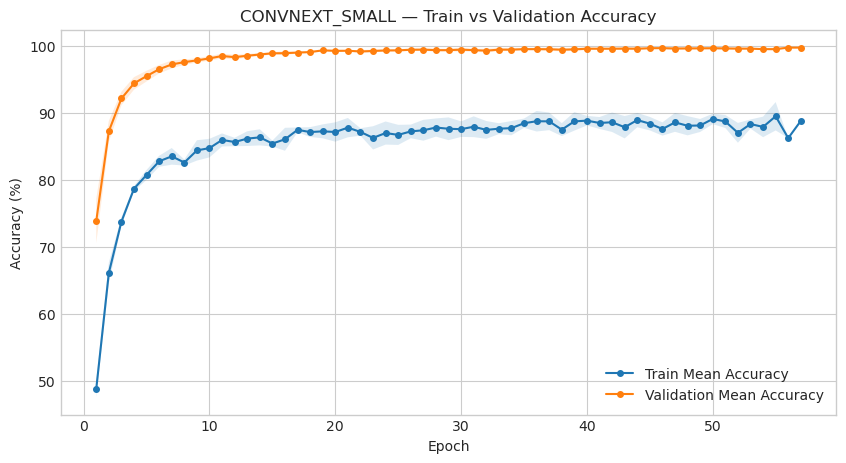

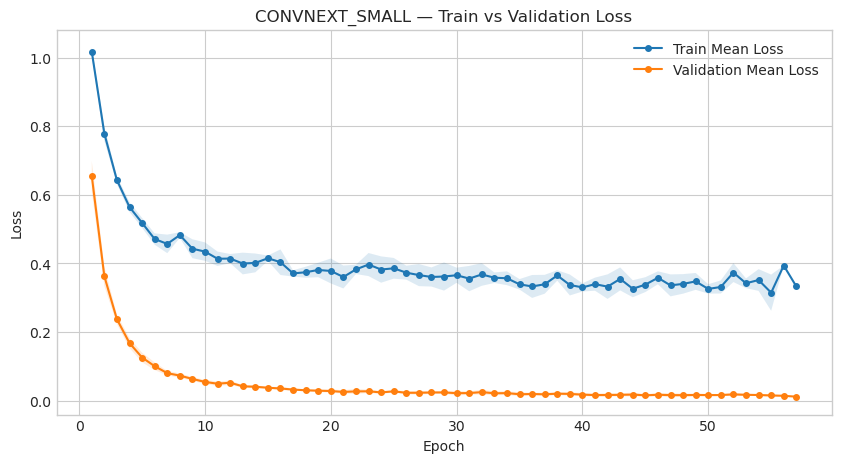

Plots successfully generated and saved to: ./output_plots


In [7]:
# --- 6.5. Model Comparison Plotting (Accuracy & Loss Only) ---

import matplotlib.pyplot as plt
import numpy as np
import os

def pad_histories(list_of_hist_lists, key):
    """Pads lists of different lengths with NaN to create a uniform NumPy array."""
    sequences = [np.array(h.get(key, [])) for h in list_of_hist_lists]
    if not any(s.size > 0 for s in sequences):
        return np.array([]), 0

    max_len = max(len(s) for s in sequences if s.size > 0)
    arr = np.full((len(sequences), max_len), np.nan, dtype=float)

    for i, s in enumerate(sequences):
        if s.size > 0:
            arr[i, :len(s)] = s

    return arr, max_len

try:
    print("\n" + "="*50)
    # --- Check and Print Total Training Time ---
    if 'total_training_time_seconds' in globals():
        mins, secs = divmod(total_training_time_seconds, 60)
        hours, mins = divmod(mins, 60)
        print(f"TOTAL TRAINING TIME: {int(hours)}h {int(mins)}m {secs:.2f}s")
    else:
        print("Total training time not found. (Make sure you added the timer to the training block)")
    print("="*50 + "\n")

    print("--- Generating Accuracy and Loss Plots ---")
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # Ensure the output directory exists
    os.makedirs(out_root, exist_ok=True)

    for model_name in MODEL_NAMES:
        model_histories = histories.get(model_name, [])
        if not model_histories:
            print(f"Skipping {model_name}, no history found.")
            continue

        # Extract padded arrays for accuracy and loss
        val_acc_arr, max_epochs = pad_histories(model_histories, 'val_acc')
        train_acc_arr, _ = pad_histories(model_histories, 'train_acc')
        val_loss_arr, _ = pad_histories(model_histories, 'val_loss')
        train_loss_arr, _ = pad_histories(model_histories, 'train_loss')

        if max_epochs == 0:
            continue

        epochs = np.arange(1, max_epochs + 1)

        # Calculate means and standard deviations across folds
        val_acc_mean = np.nanmean(val_acc_arr, axis=0)
        val_acc_std = np.nanstd(val_acc_arr, axis=0)
        train_acc_mean = np.nanmean(train_acc_arr, axis=0)
        train_acc_std = np.nanstd(train_acc_arr, axis=0)
        
        val_loss_mean = np.nanmean(val_loss_arr, axis=0)
        val_loss_std = np.nanstd(val_loss_arr, axis=0)
        train_loss_mean = np.nanmean(train_loss_arr, axis=0)
        train_loss_std = np.nanstd(train_loss_arr, axis=0)

        # ---------------------------------------------------------
        # GRAPH 1: ACCURACY GRAPH
        # ---------------------------------------------------------
        plt.figure(figsize=(10, 5))
        plt.plot(epochs, train_acc_mean, label='Train Mean Accuracy', marker='o', markersize=4)
        plt.fill_between(epochs, train_acc_mean - train_acc_std, train_acc_mean + train_acc_std, alpha=0.15)
        
        plt.plot(epochs, val_acc_mean, label='Validation Mean Accuracy', marker='o', markersize=4)
        plt.fill_between(epochs, val_acc_mean - val_acc_std, val_acc_mean + val_acc_std, alpha=0.15)
        
        plt.title(f'{model_name.upper()} — Train vs Validation Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy (%)')
        plt.legend()
        plt.grid(True)
        plt.savefig(os.path.join(out_root, f"{model_name}_train_vs_val_acc.png")) 
        plt.show() 
        plt.close()
        
        # ---------------------------------------------------------
        # GRAPH 2: LOSS GRAPH
        # ---------------------------------------------------------
        plt.figure(figsize=(10, 5))
        plt.plot(epochs, train_loss_mean, label='Train Mean Loss', marker='o', markersize=4)
        plt.fill_between(epochs, train_loss_mean - train_loss_std, train_loss_mean + train_loss_std, alpha=0.15)
        
        plt.plot(epochs, val_loss_mean, label='Validation Mean Loss', marker='o', markersize=4)
        plt.fill_between(epochs, val_loss_mean - val_loss_std, val_loss_mean + val_loss_std, alpha=0.15)
        
        plt.title(f'{model_name.upper()} — Train vs Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.savefig(os.path.join(out_root, f"{model_name}_train_vs_val_loss.png"))
        plt.show() 
        plt.close()

    print(f"Plots successfully generated and saved to: {out_root}")

except Exception as e:
    print(f"AN ERROR OCCURRED DURING PLOTTING: {e}")

## 7. Final Evaluation & TTA

Now that training is done, we evaluate the ensemble of our 5 models.

**Test Time Augmentation (TTA):**  
For every image in the test set, we do the following:

1. Pass the original image through the model.
2. Pass a horizontally flipped version of the image through the model.
3. Average the predictions.

This usually boosts accuracy by 1–2% because the model gets "two opinions" on the same image.

--- Starting Final Evaluation ---
Building ConvNeXt Small model for 3 classes with dropout 0.6...
Loaded convnext_small_fold1_best.pth
Building ConvNeXt Small model for 3 classes with dropout 0.6...
Loaded convnext_small_fold2_best.pth
Building ConvNeXt Small model for 3 classes with dropout 0.6...
Loaded convnext_small_fold3_best.pth
Building ConvNeXt Small model for 3 classes with dropout 0.6...
Loaded convnext_small_fold4_best.pth
Building ConvNeXt Small model for 3 classes with dropout 0.6...
Loaded convnext_small_fold5_best.pth
Loading test data from: /mnt/c/Users/klood/Desktop/Grad project/cnn_classfication/final_models/farm_test/testf_new_final
Running Inference with TTA...


Testing: 100%|████████████████████████████████████████████████████████████████████████| 735/735 [02:06<00:00,  5.80it/s]



Final Ensemble Accuracy:      98.23%
Total Pure Inference Time:    116.98 seconds
Pure Inference Time/Image:    159.16 ms

Classification Report:

              precision    recall  f1-score   support

      KHALAS       1.00      0.99      0.99       245
      RAZEEZ       0.97      0.98      0.98       248
      SHISHI       0.98      0.97      0.98       242

    accuracy                           0.98       735
   macro avg       0.98      0.98      0.98       735
weighted avg       0.98      0.98      0.98       735



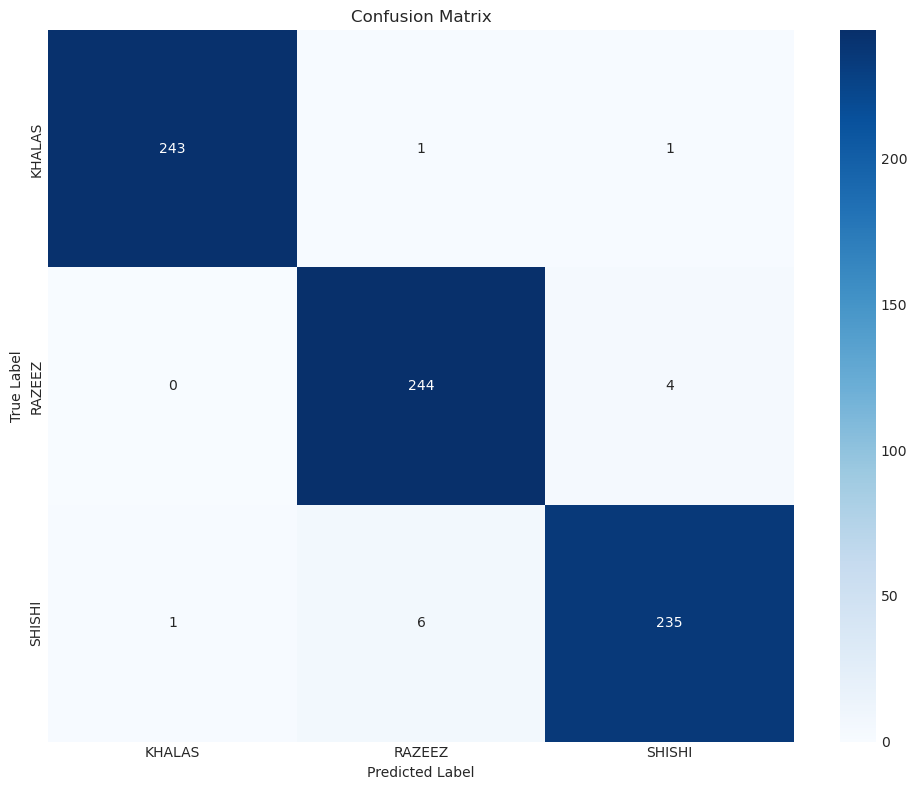

In [8]:
import time
import torch
import os
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import datasets
from torch.utils.data import DataLoader

# --- FINAL EVALUATION WITH TTA ---
USE_TTA = True

# 1. UPDATE THIS PATH TO YOUR TEST FOLDER
TEST_DATASET_PATH = r"/mnt/c/Users/klood/Desktop/Grad project/cnn_classfication/final_models/farm_test/testf_new_final"

def plot_confusion_matrix_custom(cm, class_names):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

def evaluate_on_final_test():
    print("--- Starting Final Evaluation ---")
    
    # Load all fold models
    models_list = []
    for fold in range(1, N_SPLITS + 1):
        model_path = f"convnext_small_fold{fold}_best.pth"
        if os.path.exists(model_path):
            model = create_convnext_small(len(class_names), dropout_rate=DEFAULT_DROPOUT_RATE)
            # FIX: Added weights_only=True
            model.load_state_dict(torch.load(model_path, map_location=DEVICE, weights_only=True))
            model.to(DEVICE)
            model.eval()
            models_list.append(model)
            print(f"Loaded {model_path}")
            
    if not models_list:
        print("No models found for evaluation!")
        return

    print(f"Loading test data from: {TEST_DATASET_PATH}")
    test_folder_dataset = datasets.ImageFolder(root=TEST_DATASET_PATH)
    test_paths = [s[0] for s in test_folder_dataset.samples]
    test_labels = [s[1] for s in test_folder_dataset.samples]
    
    test_loader = DataLoader(
        PalmTreeDataset(test_paths, test_labels, transform=val_test_transforms),
        batch_size=1, shuffle=False
    )
    
    y_true = []
    y_pred = []
    
    # Accumulator for pure inference time
    pure_inference_time = 0.0 
    
    print("Running Inference with TTA...")
    
    with torch.no_grad():
        for image, label in tqdm(test_loader, desc="Testing"):
            image = image.to(DEVICE)
            
            # --- START PURE INFERENCE TIMER ---
            # FIX: Corrected DEVICE.type comparison
            if DEVICE.type == 'cuda': torch.cuda.synchronize()
            start_time = time.time()
            
            preds_stack = []
            for model in models_list:
                # FIX: Updated autocast syntax
                with torch.autocast(device_type=DEVICE.type, dtype=torch.float16):
                    out = model(image)
                    preds_stack.append(torch.softmax(out, dim=1))
                    
                    if USE_TTA:
                        image_flipped = torch.flip(image, [3])
                        out_flip = model(image_flipped)
                        preds_stack.append(torch.softmax(out_flip, dim=1))
            
            avg_pred = torch.stack(preds_stack).mean(dim=0)
            final_cls = torch.argmax(avg_pred, dim=1).item()
            
            # --- END PURE INFERENCE TIMER ---
            # FIX: Corrected DEVICE.type comparison
            if DEVICE.type == 'cuda': torch.cuda.synchronize()
            pure_inference_time += (time.time() - start_time)
            
            y_true.append(label.item())
            y_pred.append(final_cls)

    # Metrics Calculations
    num_images = len(test_loader.dataset)
    time_per_image_ms = (pure_inference_time / num_images) * 1000 if num_images > 0 else 0

    accuracy = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=class_names)
    cm = confusion_matrix(y_true, y_pred)
    
    print("\n" + "="*45)
    print(f"Final Ensemble Accuracy:      {accuracy*100:.2f}%")
    print(f"Total Pure Inference Time:    {pure_inference_time:.2f} seconds")
    print(f"Pure Inference Time/Image:    {time_per_image_ms:.2f} ms")
    print("="*45)
    print("\nClassification Report:\n")
    print(report)
    
    plot_confusion_matrix_custom(cm, class_names)

evaluate_on_final_test()